# SONYC Dataset Exploration
CLAP embeddings + UMAP + clustering. Run cells top to bottom.

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
import umap
import warnings
warnings.filterwarnings('ignore')

# load embeddings
embs = np.load('embeddings.npy')          # (18510, 512)
embs = normalize(embs, norm='l2')         # unit sphere (should already be, just in case)

# load metadata
meta = []
with open('embeddings_meta.jsonl') as f:
    for line in f:
        meta.append(json.loads(line))

print(f'embeddings: {embs.shape}')
print(f'metadata rows: {len(meta)}')
print(f'sample: {meta[0]}')

embeddings: (18510, 512)
metadata rows: 18510
sample: {'filename': '00_000357.wav', 'archive': 0, 'borough': '1', 'hour': 22, 'classes': ['medium-sounding-engine', 'non-machinery-impact'], 'gt': True}


In [3]:
# coarse class label for each clip (from first labeled class, or 'unlabeled')
# fine class -> coarse class mapping
FINE_TO_COARSE = {
    'small-sounding-engine': 'engine', 'medium-sounding-engine': 'engine', 'large-sounding-engine': 'engine',
    'rock-drill': 'machinery', 'jackhammer': 'machinery', 'hoe-ram': 'machinery', 'pile-driver': 'machinery',
    'non-machinery-impact': 'impact',
    'chainsaw': 'saw', 'small-medium-rotating-saw': 'saw', 'large-rotating-saw': 'saw',
    'car-horn': 'alert', 'car-alarm': 'alert', 'siren': 'alert', 'reverse-beeper': 'alert',
    'stationary-music': 'music', 'mobile-music': 'music', 'ice-cream-truck': 'music',
    'person-or-small-group-talking': 'voice', 'person-or-small-group-shouting': 'voice',
    'large-crowd': 'voice', 'amplified-speech': 'voice',
    'dog-barking-whining': 'dog',
}
COARSE_COLORS = {
    'engine': '#ff6b6b', 'machinery': '#ff9f43', 'impact': '#ffd32a',
    'saw': '#26de81', 'alert': '#fd79a8', 'music': '#a29bfe',
    'voice': '#74b9ff', 'dog': '#55efc4', 'unlabeled': '#333344',
}

def get_coarse(m):
    for c in m.get('classes', []):
        # match fine class name to coarse
        for fine, coarse in FINE_TO_COARSE.items():
            if fine in c:
                return coarse
    return 'unlabeled'

labels = [get_coarse(m) for m in meta]
colors = [COARSE_COLORS[l] for l in labels]
boroughs = [m.get('borough', '') for m in meta]
hours = [m.get('hour', -1) for m in meta]

from collections import Counter
print('label distribution:', Counter(labels).most_common())

label distribution: [('unlabeled', 17276), ('engine', 607), ('voice', 244), ('impact', 182), ('alert', 115), ('music', 36), ('machinery', 22), ('saw', 17), ('dog', 11)]


In [ ]:
# UMAP — takes ~3-5 min on 18k clips
# reduce first with PCA for speed
from sklearn.decomposition import PCA

print('PCA to 50 dims...')
pca = PCA(n_components=50, random_state=42)
embs_pca = pca.fit_transform(embs)
print(f'  variance explained: {pca.explained_variance_ratio_.sum():.1%}')

print('UMAP to 2D...')
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, metric='cosine', random_state=13)
embs_2d = reducer.fit_transform(embs_pca)
print('done.')

PCA to 50 dims...
  variance explained: 94.5%
UMAP to 2D...
done.


In [ ]:
# full dataset UMAP — colored by coarse class
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('#070810')
fig.patch.set_facecolor('#070810')

for label, color in COARSE_COLORS.items():
    mask = np.array(labels) == label
    if mask.sum() == 0:
        continue
    ax.scatter(embs_2d[mask, 0], embs_2d[mask, 1],
               c=color, s=2, alpha=0.5, label=f'{label} ({mask.sum()})', linewidths=0)

ax.legend(loc='upper right', fontsize=9, framealpha=0.3,
          labelcolor='white', facecolor='#12152a')
ax.set_title('SONYC — CLAP embedding space (UMAP)\neach point = one 10s clip, position = acoustic similarity', color='white', fontsize=13)
ax.set_xlabel('UMAP dimension 1  (no physical meaning — closer = more acoustically similar)', color='#5a5f8a', fontsize=9)
ax.set_ylabel('UMAP dimension 2', color='#5a5f8a', fontsize=9)
ax.tick_params(colors='#5a5f8a')
for spine in ax.spines.values():
    spine.set_edgecolor('#1e2240')
plt.tight_layout()
plt.savefig('umap_coarse.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved umap_coarse.png')

In [ ]:
# UMAP colored by borough (1=Manhattan, 3=Brooklyn, 4=Queens)
BOROUGH_COLORS = {'1': '#74b9ff', '3': '#a29bfe', '4': '#55efc4', '': '#333344'}
BOROUGH_NAMES  = {'1': 'Manhattan', '3': 'Brooklyn', '4': 'Queens', '': 'unknown'}

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('#070810')
fig.patch.set_facecolor('#070810')

for b, color in BOROUGH_COLORS.items():
    mask = np.array(boroughs) == b
    if mask.sum() == 0:
        continue
    ax.scatter(embs_2d[mask, 0], embs_2d[mask, 1],
               c=color, s=2, alpha=0.4,
               label=f'{BOROUGH_NAMES[b]} ({mask.sum()})', linewidths=0)

ax.legend(loc='upper right', fontsize=10, framealpha=0.3,
          labelcolor='white', facecolor='#12152a')
ax.set_title('SONYC — same CLAP space, colored by recording borough\noverlapping clusters = boroughs sound alike in those regions', color='white', fontsize=13)
ax.set_xlabel('UMAP dimension 1  (no physical meaning — closer = more acoustically similar)', color='#5a5f8a', fontsize=9)
ax.set_ylabel('UMAP dimension 2', color='#5a5f8a', fontsize=9)
ax.tick_params(colors='#5a5f8a')
for spine in ax.spines.values():
    spine.set_edgecolor('#1e2240')
plt.tight_layout()
plt.savefig('umap_borough.png', dpi=150, bbox_inches='tight')
plt.show()

## Why 93% is "unlabeled"

Not a data quality problem — it's how the SONYC annotation process worked.

The dataset has two annotation tiers:
- **Citizen science** (~18,500 clips): Zooniverse volunteers tagged everything, but with varying agreement and no verification
- **Ground truth** (~1,200 clips, annotator_id=0): SONYC team verified these manually — this is what benchmarks and models use

Our embeddings only attach labels from ground-truth annotations. The other 17k clips are real NYC audio — engines, voices, construction — just not expert-reviewed. CLAP embedded them on acoustics alone, so they land in the right neighborhoods in the UMAP even without a label.

**This is actually useful:** text retrieval (cell 8) can surface unlabeled clips that *sound like* a jackhammer or dog, giving us a much larger pool to pick from than just the 1,200 GT clips.

In [ ]:
# zoomed UMAP — labeled clips bright + large, unlabeled as faint background
labeled_mask = np.array([len(m.get('classes', [])) > 0 for m in meta])
n_labeled = labeled_mask.sum()
print(f'{n_labeled} GT-labeled clips ({n_labeled/len(meta):.1%}) out of {len(meta)}')
print(f'GT means annotator_id=0 (SONYC team verified) — not the same as "has sound"')
print(f'The ~17k unlabeled clips are real city audio, just not expert-reviewed')

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('#070810')
fig.patch.set_facecolor('#070810')

# unlabeled as dim background
ax.scatter(embs_2d[~labeled_mask, 0], embs_2d[~labeled_mask, 1],
           c='#12152a', s=1, alpha=0.5, linewidths=0, label=f'unlabeled ({(~labeled_mask).sum()})')

# labeled on top, large + bright
for label, color in COARSE_COLORS.items():
    if label == 'unlabeled':
        continue
    mask = np.array(labels) == label
    if mask.sum() == 0:
        continue
    ax.scatter(embs_2d[mask, 0], embs_2d[mask, 1],
               c=color, s=25, alpha=0.9, label=f'{label} ({mask.sum()})', linewidths=0)

ax.legend(loc='upper right', fontsize=9, framealpha=0.4, labelcolor='white', facecolor='#12152a')
ax.set_title('UMAP — GT-labeled clips highlighted over the full dataset\n'
             'clusters = CLAP learned acoustic similarity without using any labels',
             color='white', fontsize=13)
ax.set_xlabel('UMAP dimension 1  (no physical meaning — closer = sounds more alike)', color='#5a5f8a', fontsize=9)
ax.set_ylabel('UMAP dimension 2', color='#5a5f8a', fontsize=9)
ax.tick_params(colors='#5a5f8a')
for spine in ax.spines.values():
    spine.set_edgecolor('#1e2240')
plt.tight_layout()
plt.savefig('umap_labeled_highlight.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# when do sounds peak? hour × class heatmap
# each row (class) normalized to its own max so rare sounds are still readable

from collections import defaultdict

COARSE_ORDER = ['engine', 'machinery', 'impact', 'saw', 'alert', 'music', 'voice', 'dog']

hour_class = defaultdict(lambda: defaultdict(int))
for m in meta:
    h = m.get('hour', -1)
    if h < 0 or not m.get('classes'):
        continue
    seen = set()
    for cls in m['classes']:
        for fine, coarse in FINE_TO_COARSE.items():
            if fine in cls and coarse not in seen:
                hour_class[h][coarse] += 1
                seen.add(coarse)

matrix = np.array([[hour_class[h].get(c, 0) for c in COARSE_ORDER] for h in range(24)], dtype=float)

# normalize each class column to its own max (so rare classes like 'dog' still show pattern)
col_max = matrix.max(axis=0)
col_max[col_max == 0] = 1
matrix_norm = (matrix / col_max).T  # shape: (n_classes, 24)

fig, ax = plt.subplots(figsize=(16, 5))
ax.set_facecolor('#070810')
fig.patch.set_facecolor('#070810')

im = ax.imshow(matrix_norm, aspect='auto', cmap='magma', interpolation='nearest', vmin=0, vmax=1)
ax.set_yticks(range(len(COARSE_ORDER)))
ax.set_yticklabels(COARSE_ORDER, color='white', fontsize=10)
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h}:00' for h in range(24)], color='#5a5f8a', fontsize=8, rotation=45)
ax.set_title('When do sounds peak? (each row normalized to its own max — shows relative daily rhythm)',
             color='white', fontsize=12)
ax.set_xlabel('hour of day', color='#5a5f8a')

# annotate raw counts (skip zeros)
for j in range(24):
    for i, c in enumerate(COARSE_ORDER):
        v = int(matrix[j, i])
        if v > 0:
            ax.text(j, i, str(v), ha='center', va='center', fontsize=6,
                    color='white' if matrix_norm[i, j] > 0.5 else '#666688')

plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01, label='relative intensity')
for spine in ax.spines.values():
    spine.set_edgecolor('#1e2240')
plt.tight_layout()
plt.savefig('hour_class_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('peak hour per class:')
for i, c in enumerate(COARSE_ORDER):
    peak_h = int(np.argmax(matrix[:, i]))
    peak_count = int(matrix[peak_h, i])
    print(f'  {c:<12} peaks at {peak_h:02d}:00  ({peak_count} clips)')

In [ ]:
# borough × sound class — what share of each borough's GT clips is each sound type?
from collections import defaultdict

COARSE_ORDER = ['engine', 'machinery', 'impact', 'saw', 'alert', 'music', 'voice', 'dog']
BOROUGH_ORDER = ['1', '3', '4']
BOROUGH_LABEL = {'1': 'Manhattan', '3': 'Brooklyn', '4': 'Queens'}

bor_class = defaultdict(lambda: defaultdict(int))
for m in meta:
    b = m.get('borough', '')
    if b not in BOROUGH_ORDER or not m.get('classes'):
        continue
    seen = set()
    for cls in m['classes']:
        for fine, coarse in FINE_TO_COARSE.items():
            if fine in cls and coarse not in seen:
                bor_class[b][coarse] += 1
                seen.add(coarse)

matrix_b = np.array([[bor_class[b].get(c, 0) for c in COARSE_ORDER] for b in BOROUGH_ORDER], dtype=float)
row_sums = matrix_b.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
matrix_b_norm = matrix_b / row_sums

fig, ax = plt.subplots(figsize=(12, 3))
ax.set_facecolor('#070810')
fig.patch.set_facecolor('#070810')

im = ax.imshow(matrix_b_norm, aspect='auto', cmap='magma', interpolation='nearest')
ax.set_yticks(range(3))
ax.set_yticklabels([BOROUGH_LABEL[b] for b in BOROUGH_ORDER], color='white', fontsize=11)
ax.set_xticks(range(len(COARSE_ORDER)))
ax.set_xticklabels(COARSE_ORDER, color='#5a5f8a', fontsize=10)
ax.set_title("Sound class share by borough (% of that borough's GT-labeled clips)", color='white', fontsize=12)

for i, b in enumerate(BOROUGH_ORDER):
    for j, c in enumerate(COARSE_ORDER):
        raw = int(matrix_b[i, j])
        pct = matrix_b_norm[i, j] * 100
        if raw > 0:
            ax.text(j, i, f'{pct:.0f}%\n({raw})', ha='center', va='center',
                    fontsize=8, color='white' if matrix_b_norm[i, j] > 0.3 else '#888888')

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.01)
for spine in ax.spines.values():
    spine.set_edgecolor('#1e2240')
plt.tight_layout()
plt.savefig('borough_class_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# also print totals per borough
for b in BOROUGH_ORDER:
    total = sum(bor_class[b].values())
    print(f'{BOROUGH_LABEL[b]:12s}: {total} GT-labeled sound occurrences')

In [7]:
# per-class: find 5 most representative (near centroid) + 5 most outlier
# output: candidates.json for Gemini captioning later

FINE_CLASSES = [
    'small-engine', 'medium-engine', 'large-engine',
    'rock-drill', 'jackhammer', 'hoe-ram', 'pile-driver',
    'impact', 'chainsaw', 'small-saw', 'large-saw',
    'car-horn', 'car-alarm', 'siren', 'reverse-beeper',
    'stationary-music', 'mobile-music', 'ice-cream-truck',
    'talking', 'shouting', 'large-crowd', 'amplified-speech', 'dog',
]

# fine class name -> list of indices
FINE_COL_NAMES = {
    'small-engine': 'small-sounding-engine',
    'medium-engine': 'medium-sounding-engine',
    'large-engine': 'large-sounding-engine',
    'small-saw': 'small-medium-rotating-saw',
    'large-saw': 'large-rotating-saw',
    'talking': 'person-or-small-group-talking',
    'shouting': 'person-or-small-group-shouting',
    'large-crowd': 'large-crowd',
    'dog': 'dog-barking-whining',
}

def class_indices(fine_class):
    search = FINE_COL_NAMES.get(fine_class, fine_class)
    return [i for i, m in enumerate(meta) if any(search in c for c in m.get('classes', []))]

candidates = {}
for cls in FINE_CLASSES:
    idxs = class_indices(cls)
    if len(idxs) < 5:
        print(f'  {cls}: only {len(idxs)} clips, skipping')
        continue
    cls_embs = embs[idxs]
    centroid = cls_embs.mean(axis=0)
    centroid = centroid / np.linalg.norm(centroid)
    # cosine similarity to centroid (embs already unit-norm)
    sims = cls_embs @ centroid
    order = np.argsort(sims)  # ascending = outliers first
    top_representative = [idxs[i] for i in order[-5:][::-1]]   # highest sim
    top_outlier        = [idxs[i] for i in order[:5]]           # lowest sim
    candidates[cls] = {
        'n_total': len(idxs),
        'representative': [{'idx': int(i), **meta[i], 'centroid_sim': float(sims[order.tolist().index(idxs.index(i))])} for i in top_representative],
        'outlier':        [{'idx': int(i), **meta[i], 'centroid_sim': float(sims[order.tolist().index(idxs.index(i))])} for i in top_outlier],
    }
    print(f'  {cls:25s} {len(idxs):5d} clips | rep sim: {sims[order[-1]]:.3f} | outlier sim: {sims[order[0]]:.3f}')

with open('candidates.json', 'w') as f:
    json.dump(candidates, f, indent=2)
print('\nsaved candidates.json')

  small-engine                 18 clips | rep sim: 0.896 | outlier sim: 0.588
  medium-engine               248 clips | rep sim: 0.939 | outlier sim: 0.351
  large-engine                406 clips | rep sim: 0.937 | outlier sim: 0.456
  rock-drill                    6 clips | rep sim: 0.857 | outlier sim: 0.788
  jackhammer                   20 clips | rep sim: 0.918 | outlier sim: 0.615
  hoe-ram: only 2 clips, skipping
  pile-driver: only 2 clips, skipping
  impact                      348 clips | rep sim: 0.935 | outlier sim: 0.418
  chainsaw                      5 clips | rep sim: 0.930 | outlier sim: 0.644
  small-saw                    16 clips | rep sim: 0.871 | outlier sim: 0.631
  large-saw                     7 clips | rep sim: 0.887 | outlier sim: 0.639
  car-horn                    157 clips | rep sim: 0.945 | outlier sim: 0.525
  car-alarm: only 1 clips, skipping
  siren                       106 clips | rep sim: 0.948 | outlier sim: 0.518
  reverse-beeper               33 

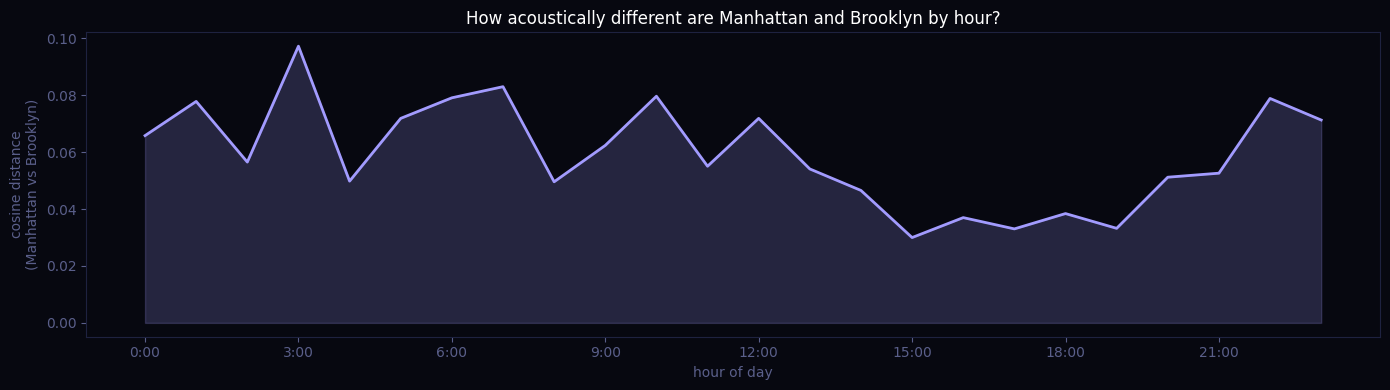

most different hour:  3:00 (distance 0.0973)
most similar hour:   15:00  (distance 0.0300)


In [8]:
# borough × hour heatmap — how much do Manhattan and Brooklyn differ acoustically?
# compute average embedding per borough per hour, then cosine distance between boroughs

from sklearn.metrics.pairwise import cosine_distances

borough_hour_embs = {}  # (borough, hour) -> mean embedding
for i, m in enumerate(meta):
    b = m.get('borough', '')
    h = m.get('hour', -1)
    if b not in ('1', '3') or h < 0:
        continue
    key = (b, h)
    if key not in borough_hour_embs:
        borough_hour_embs[key] = []
    borough_hour_embs[key].append(embs[i])

# average and normalize
avg = {k: normalize(np.mean(v, axis=0, keepdims=True))[0] for k, v in borough_hour_embs.items()}

# cosine distance between Manhattan and Brooklyn per hour
hours_range = range(24)
distances = []
for h in hours_range:
    m_emb = avg.get(('1', h))
    b_emb = avg.get(('3', h))
    if m_emb is not None and b_emb is not None:
        d = float(cosine_distances([m_emb], [b_emb])[0][0])
    else:
        d = None
    distances.append(d)

# plot
fig, ax = plt.subplots(figsize=(14, 4))
ax.set_facecolor('#070810')
fig.patch.set_facecolor('#070810')

valid_h = [h for h, d in zip(hours_range, distances) if d is not None]
valid_d = [d for d in distances if d is not None]

ax.plot(valid_h, valid_d, color='#a29bfe', linewidth=2)
ax.fill_between(valid_h, valid_d, alpha=0.2, color='#a29bfe')
ax.set_xlabel('hour of day', color='#5a5f8a')
ax.set_ylabel('cosine distance\n(Manhattan vs Brooklyn)', color='#5a5f8a')
ax.set_title('How acoustically different are Manhattan and Brooklyn by hour?', color='white')
ax.set_xticks(range(0, 24, 3))
ax.set_xticklabels([f'{h}:00' for h in range(0, 24, 3)], color='#5a5f8a')
ax.tick_params(colors='#5a5f8a')
for spine in ax.spines.values():
    spine.set_edgecolor('#1e2240')
plt.tight_layout()
plt.savefig('borough_distance_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

peak_h = valid_h[np.argmax(valid_d)]
min_h  = valid_h[np.argmin(valid_d)]
print(f'most different hour:  {peak_h}:00 (distance {max(valid_d):.4f})')
print(f'most similar hour:   {min_h}:00  (distance {min(valid_d):.4f})')

In [ ]:
# CLAP text retrieval — find clips nearest to a text query
# this uses the text encoder of the same model

import torch
from transformers import ClapModel, ClapProcessor

MODEL_ID = 'laion/larger_clap_music_and_speech'
processor = ClapProcessor.from_pretrained(MODEL_ID)
model = ClapModel.from_pretrained(MODEL_ID)
model.eval()

def text_query(query, top_k=10):
    """find top_k clips most similar to the text query"""
    inputs = processor(text=[query], return_tensors='pt', padding=True)
    with torch.no_grad():
        # get_text_features() returns BaseModelOutputWithPooling in transformers 5.x
        # go through text_model + text_projection directly
        text_out = model.text_model(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
        )
        text_emb = model.text_projection(text_out.pooler_output)
        text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)
    text_emb_np = text_emb.cpu().float().numpy()[0]
    sims = embs @ text_emb_np
    top_idxs = np.argsort(sims)[::-1][:top_k]
    results = []
    for idx in top_idxs:
        m = meta[idx]
        results.append({
            'sim': round(float(sims[idx]), 4),
            'filename': m['filename'],
            'archive': m['archive'],
            'borough': m.get('borough', ''),
            'hour': m.get('hour', -1),
            'classes': m.get('classes', []),
        })
    return results

# try a few
for q in [
    'jackhammer on a city street',
    'dog barking in an urban park',
    'music playing from a passing car',
    'busy intersection with horns and sirens',
    'quiet street at night',
]:
    results = text_query(q, top_k=5)
    print(f'\n"{q}"')
    for r in results:
        b = {'1': 'Manhattan', '3': 'Brooklyn', '4': 'Queens'}.get(r['borough'], '?')
        print(f'  [{r["sim"]:.3f}] {r["filename"]}  h={r["hour"]}  {b}  {r["classes"][:2]}')

In [ ]:
# your own queries — edit and re-run this cell freely
my_query = 'brooklyn street music at night'

results = text_query(my_query, top_k=15)
print(f'top results for: "{my_query}"\n')
for r in results:
    b = {'1': 'Manhattan', '3': 'Brooklyn', '4': 'Queens'}.get(r['borough'], '?')
    print(f'  [{r["sim"]:.3f}] {r["filename"]}  h={r["hour"]:2d}  {b:<12} {r["classes"][:3]}')